**1. Data Loading**

In [1]:
import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
train_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv")
test_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv")
sample_submission = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv")

**2. Exploratory Data Analysis (EDA)**

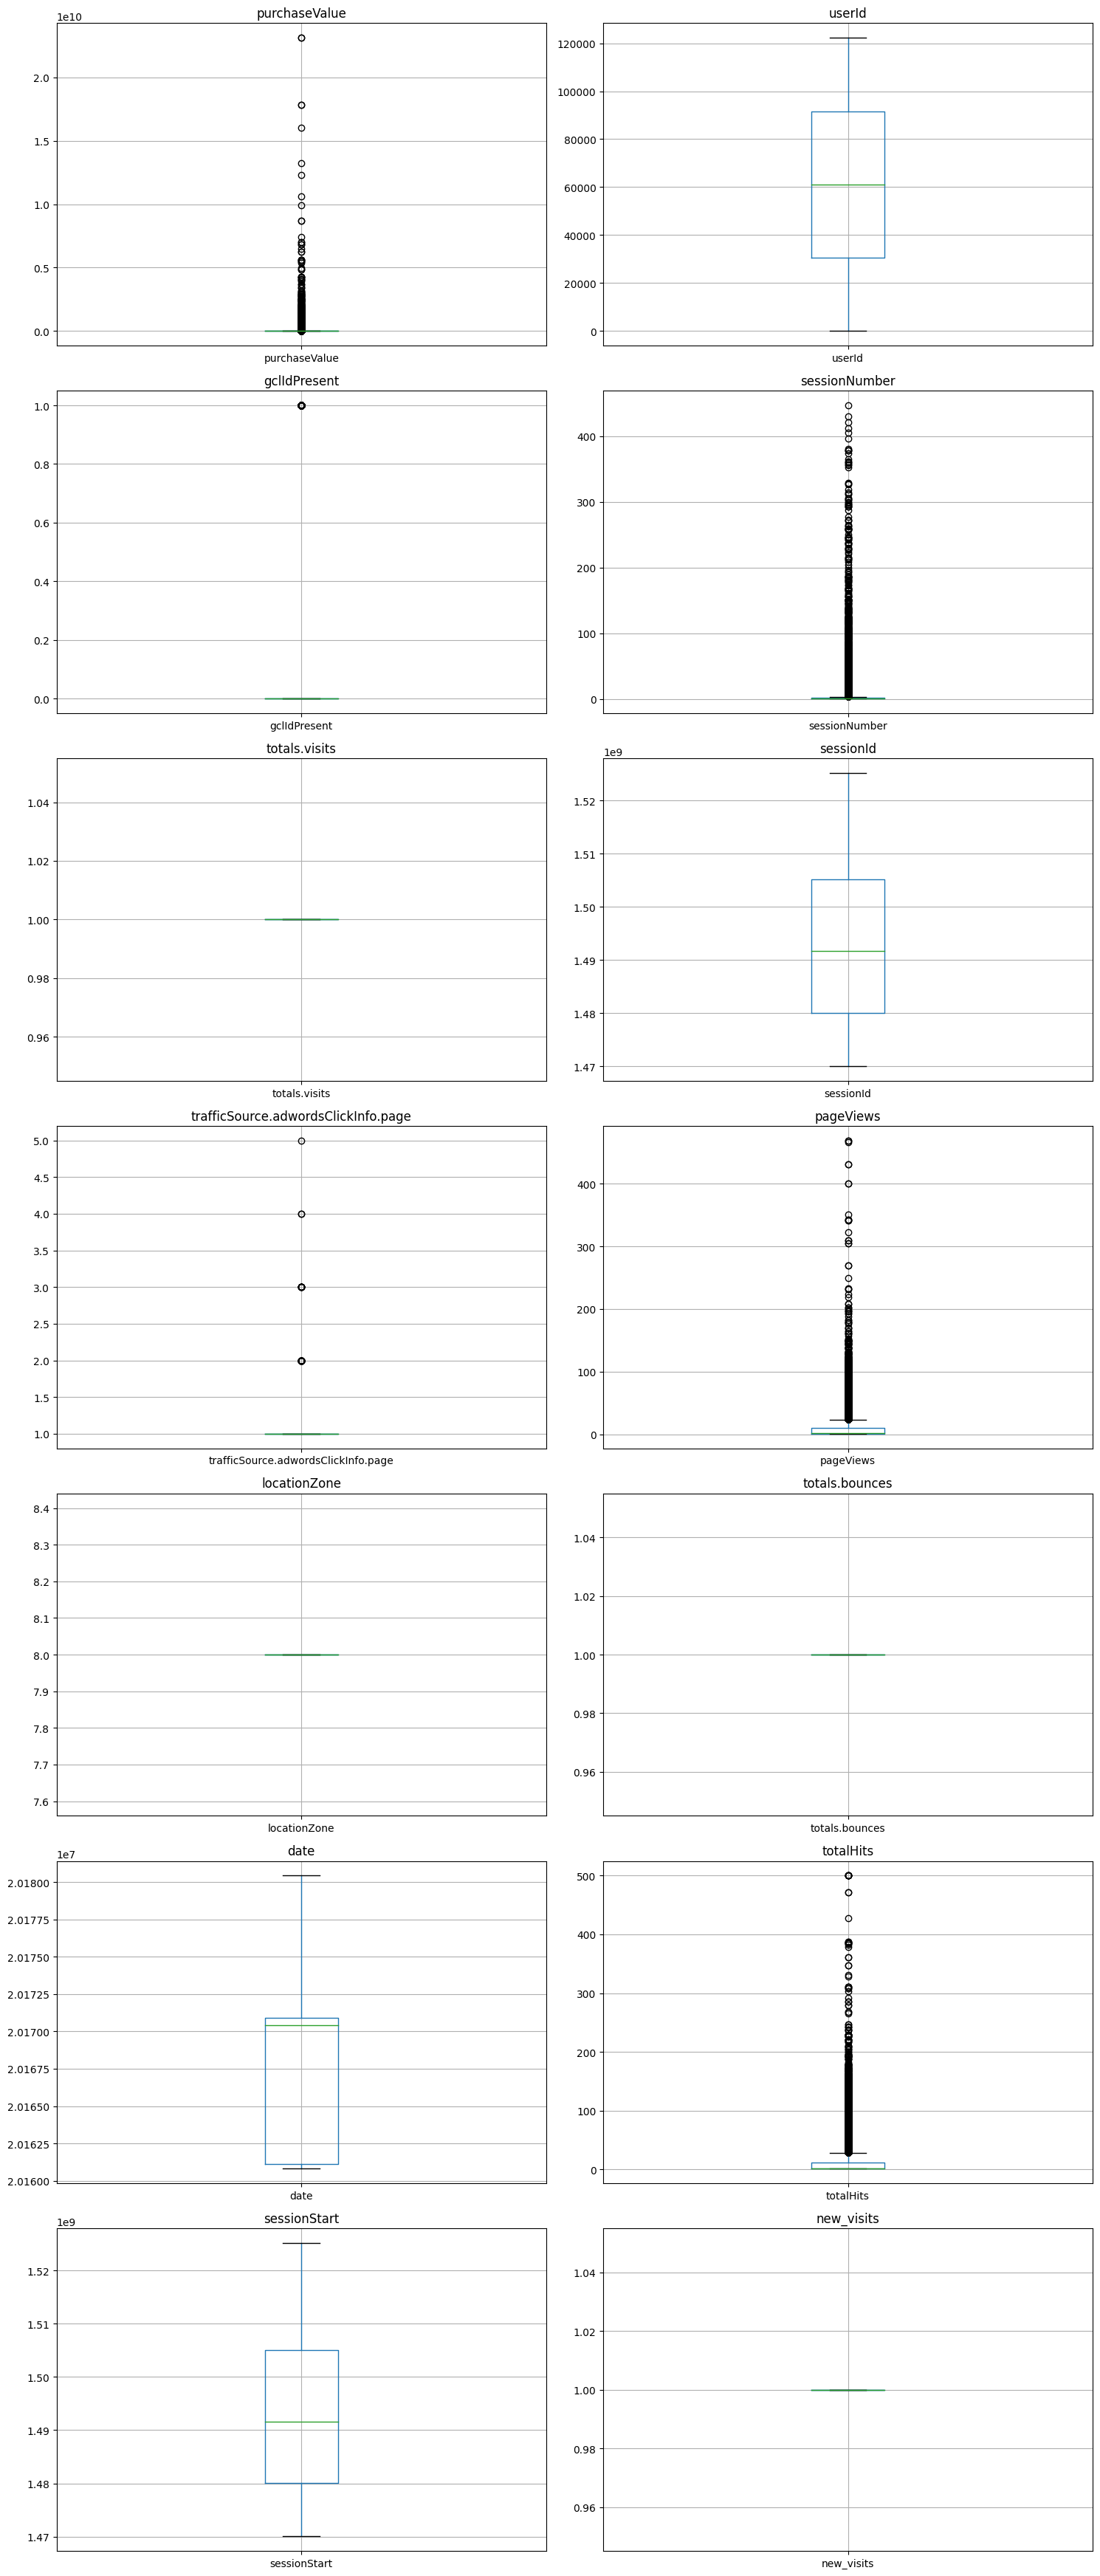

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

num_columns = len(train_df.select_dtypes(include=['float64', 'int64']).columns)
ncols = 2
nrows = (num_columns + ncols - 1) // ncols 

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

axes = axes.flatten()

numeric_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
for i, column in enumerate(numeric_columns):
    ax = axes[i]
    train_df.boxplot(column=column, ax=ax)
    ax.set_title(column)

for j in range(len(numeric_columns), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**purchaseValue:**
* Highly skewed, with many extreme outliers.
* Majority of values are near zero.
* May benefit from log transformation or robust models.


**userId:**
* Uniformly distributed, as expected for an ID column.
* Not useful as a predictive feature; consider dropping.


**gclIdPresent:**
* Binary column (0/1).
* No outliers; likely a categorical indicator.


**sessionNumber:**
* Many small values but a long tail with outliers.
* Could indicate very active users; might cap or transform.


**totals.visits:**
* Constant (always 1) – no variance.
* Should be dropped.


**sessionId:**
* Narrow range, large values – likely a timestamp or ID.
* Not meaningful for modeling unless engineered into session duration, etc.trafficSource.adwordsClickInfo.page:Mostly 1 with some higher outliers (e.g., 2–5).
* Categorical-like behavior; treat as low-cardinality ordinal.


**pageViews:**
* Highly skewed.Several sessions had extremely high page views.
* Consider log transform or capping.


**locationZone:**
* Constant (only one value) – no variance.
* Should be dropped.


**totals.bounces:**
* Constant = 1.
* No predictive power; drop it.


**date:**
* Numeric representation of date (e.g., 20170720).
* May need to extract year/month/day for temporal patterns.


**totalHits:**
* Heavy skew with many outliers.
* Like pageViews, it can dominate training if not scaled or transformed.


**sessionStart:**
* Looks like a timestamp; numeric but not directly useful.
* Feature engineering needed to extract time-of-day, weekday, etc.


**new_visits:**
* Constant = 1 – no variance.
* Drop it.


In [3]:
print(train_df.shape)

(116023, 52)


In [4]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

In [5]:
print(train_df.describe())

       purchaseValue         userId   gclIdPresent  sessionNumber  \
count   1.160230e+05  116023.000000  116023.000000  116023.000000   
mean    2.656393e+07   61094.356231       0.037019       2.691311   
std     2.051825e+08   35240.756859       0.188808      10.451613   
min     0.000000e+00       0.000000       0.000000       1.000000   
25%     0.000000e+00   30603.500000       0.000000       1.000000   
50%     0.000000e+00   61014.000000       0.000000       1.000000   
75%     0.000000e+00   91616.500000       0.000000       2.000000   
max     2.312950e+10  122276.000000       1.000000     447.000000   

       totals.visits     sessionId  trafficSource.adwordsClickInfo.page  \
count       116023.0  1.160230e+05                          4281.000000   
mean             1.0  1.493429e+09                             1.019622   
std              0.0  1.528798e+07                             0.174517   
min              1.0  1.470035e+09                             1.000000   
25%

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


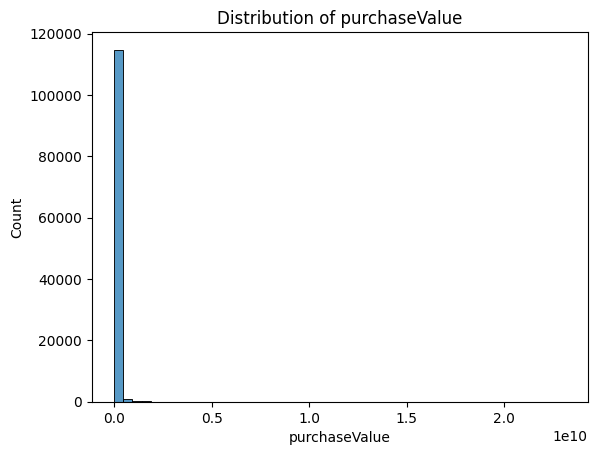

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train_df['purchaseValue'], bins=50)
plt.title("Distribution of purchaseValue")
plt.show()




**1. The histogram illustrates the distribution of the purchaseValue variable.**

**2. It is highly right-skewed, with the vast majority of purchase values concentrated at the lower end of the scale and a very long tail extending towards much higher values.**

**3. This suggests that while most transactions are of low value, there are a few exceptionally large purchases—potentially outliers—that significantly affect the distribution.**

**4. This skewness may require transformation or robust methods for modeling.**


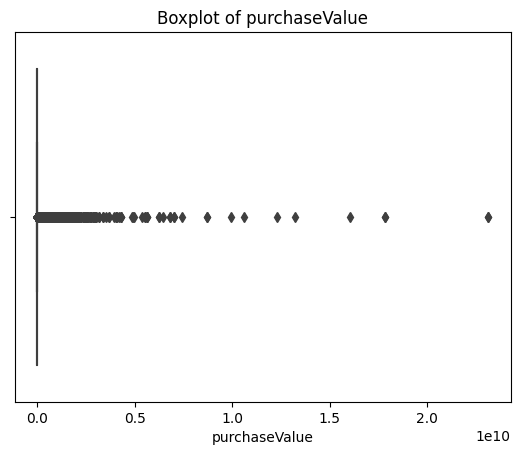

In [7]:
sns.boxplot(x=train_df['purchaseValue'])
plt.title("Boxplot of purchaseValue")
plt.show()



**1. The boxplot provides a visual summary of the spread and outliers in the purchaseValue data.**

**2. It confirms the presence of numerous extreme outliers (very high purchase values) that stretch far beyond the upper whisker.**

**3. The interquartile range is tightly packed near the lower values, showing that the bulk of data points are much smaller than the largest outliers.**

**4. This highlights the need for careful outlier handling or variable transformation to improve model performance.**




/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


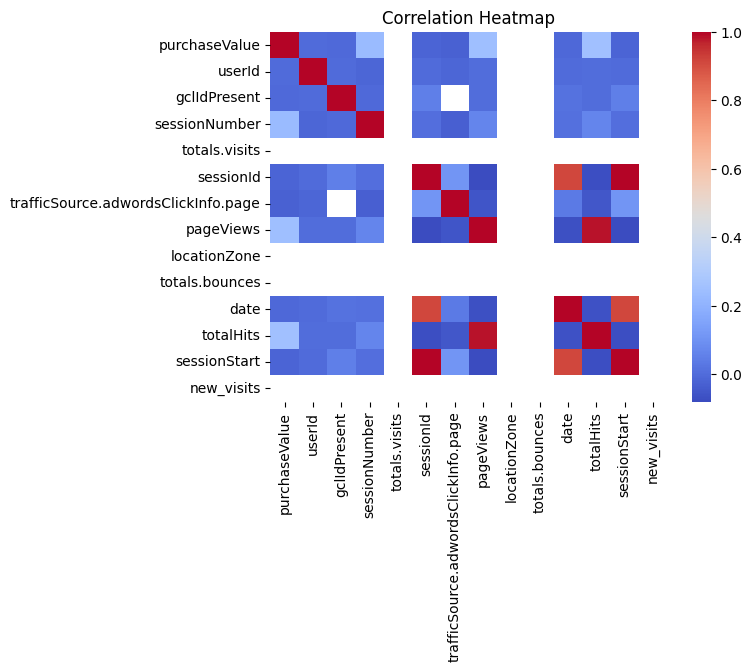

In [8]:
corr = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**1. The correlation heatmap displays the pairwise correlations between numerical features in the dataset, including purchaseValue and other user/session-level metrics.**

**2. Most features show weak or modest correlations with purchaseValue, indicating that no single feature is strongly predictive of purchase value on its own.**

**3. There are some moderate correlations between variables like sessionNumber, pageViews, and totalHits, which may reflect underlying behavioral patter**ns.

**4. Overall, this heatmap suggests the target variable (purchaseValue) is influenced by a complex combination of features rather than a single dominant one, and multicollinearity among some predictors should be considered.**


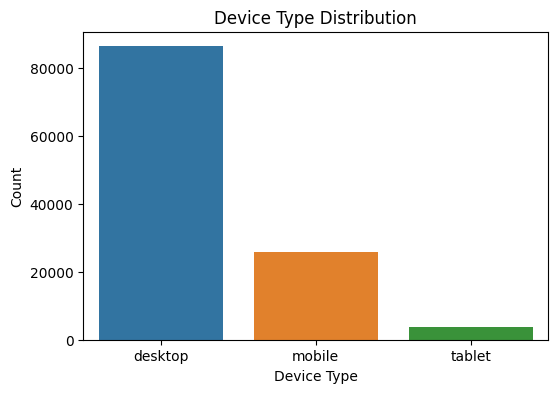

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='deviceType', data=train_df)
plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

* **This bar chart shows how many users used desktop, mobile, or tablet.**
* **This helps to understand device usage trends, which may impact UX and conversion rates.**
* **Also useful for segmentation during modeling.**

 


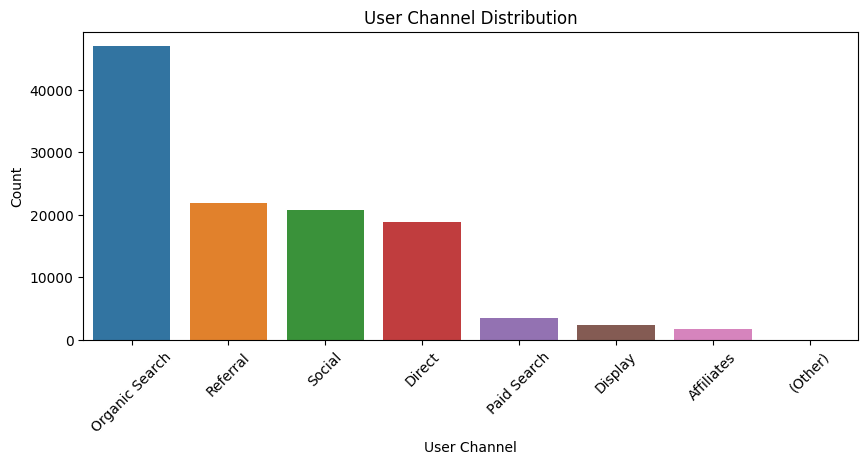

In [10]:
plt.figure(figsize=(10, 4))
sns.countplot(x='userChannel', data=train_df, order=train_df['userChannel'].value_counts().index)
plt.title("User Channel Distribution")
plt.xlabel("User Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


* **Reveals how users arrive at the platform (e.g., Direct, Social, Organic Search).**
* **Identifies the most effective acquisition channels.**
* **Crucial for marketing and campaign analysis.**



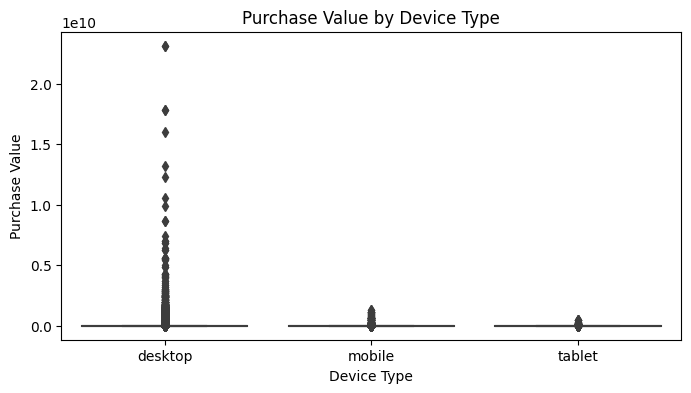

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='deviceType', y='purchaseValue', data=train_df)
plt.title("Purchase Value by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Purchase Value")
plt.show()


* **This boxplot compares how much users spend across different devices (e.g., desktop vs mobile).**
* **Helps identify which device type tends to generate higher or more variable purchases.**
* **Insights from this can guide device-specific targeting or design.**




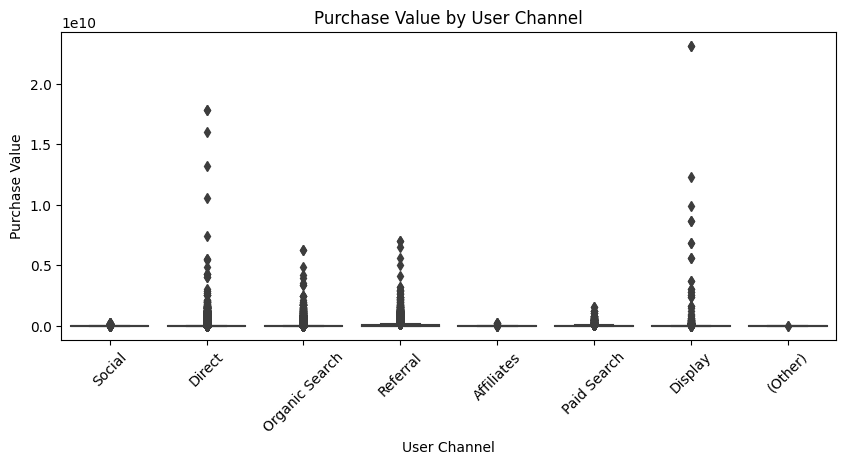

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='userChannel', y='purchaseValue', data=train_df)
plt.title("Purchase Value by User Channel")
plt.xlabel("User Channel")
plt.ylabel("Purchase Value")
plt.xticks(rotation=45)
plt.show()



* **This plot shows spending differences across marketing channels (e.g., Organic Search vs Paid Ads).**
* **We can identify high-converting channels with bigger purchases.**
* **Crucial for marketing strategy, budgeting, and performance evaluation.**


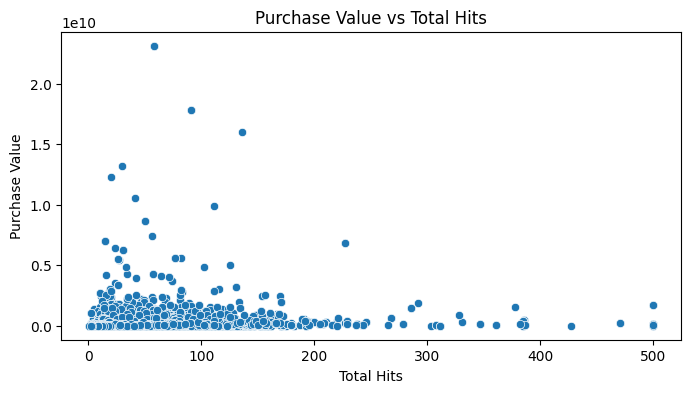

In [13]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='totalHits', y='purchaseValue', data=train_df)
plt.title("Purchase Value vs Total Hits")
plt.xlabel("Total Hits")
plt.ylabel("Purchase Value")
plt.show()



* **Each dot represents a user session.**
* **Helps visualize the relationship between user engagement (hits) and how much they spend.**
* **Can reveal trends like whether higher interaction leads to more purchases.**


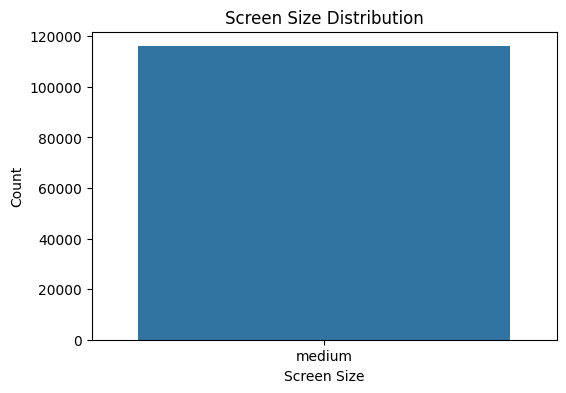

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='screenSize', data=train_df)
plt.title("Screen Size Distribution")
plt.xlabel("Screen Size")
plt.ylabel("Count")
plt.show()


* **Distribution of users based on screen size category (small, medium, large).**
* **Useful for UI/UX optimization.**
* **Can help in determining layout breakpoints or tailoring design to screen usage.**




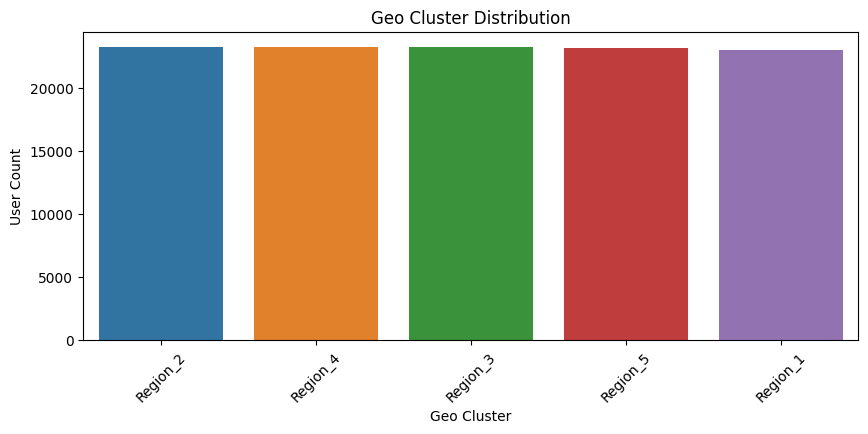

In [15]:
plt.figure(figsize=(10, 4))
sns.countplot(x='geoCluster', data=train_df, order=train_df['geoCluster'].value_counts().index)
plt.title("Geo Cluster Distribution")
plt.xlabel("Geo Cluster")
plt.ylabel("User Count")
plt.xticks(rotation=45)
plt.show()


* **Compares purchase value between mobile and non-mobile (desktop/tablet) users.**
* **Helps understand which platform drives higher purchases.**
* **May inform device-based prioritization for ads or content.**


In [16]:
train_df.isna().mean()*100

trafficSource.isTrueDirect                      63.033192
purchaseValue                                    0.000000
browser                                          0.000000
device.screenResolution                          0.000000
trafficSource.adContent                         97.446196
trafficSource.keyword                           61.936857
screenSize                                       0.000000
geoCluster                                       0.000000
trafficSource.adwordsClickInfo.slot             96.310214
device.mobileDeviceBranding                      0.000000
device.mobileInputSelector                       0.000000
userId                                           0.000000
trafficSource.campaign                           0.000000
device.mobileDeviceMarketingName                 0.000000
geoNetwork.networkDomain                         0.000000
gclIdPresent                                     0.000000
device.operatingSystemVersion                    0.000000
sessionNumber 

In [17]:
test_df.isna().mean()*100

userChannel                                      0.000000
date                                             0.000000
browser                                          0.000000
device.browserSize                               0.000000
device.browserVersion                            0.000000
deviceType                                       0.000000
device.flashVersion                              0.000000
device.isMobile                                  0.000000
device.language                                  0.000000
device.mobileDeviceBranding                      0.000000
device.mobileDeviceMarketingName                 0.000000
device.mobileDeviceModel                         0.000000
device.mobileInputSelector                       0.000000
os                                               0.000000
device.operatingSystemVersion                    0.000000
device.screenColors                              0.000000
device.screenResolution                          0.000000
geoNetwork.cit

**3. Feature Types**

In [18]:
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
numerical_cols = train_df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['trafficSource.isTrueDirect', 'browser', 'device.screenResolution', 'trafficSource.adContent', 'trafficSource.keyword', 'screenSize', 'geoCluster', 'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding', 'device.mobileInputSelector', 'trafficSource.campaign', 'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain', 'device.operatingSystemVersion', 'device.flashVersion', 'geoNetwork.region', 'trafficSource', 'geoNetwork.networkLocation', 'os', 'geoNetwork.subContinent', 'trafficSource.medium', 'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor', 'locationCountry', 'device.browserSize', 'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType', 'geoNetwork.city', 'geoNetwork.metro', 'device.mobileDeviceModel', 'trafficSource.referralPath', 'device.language', 'deviceType', 'userChannel', 'device.browserVersion', 'device.screenColors', 'geoNetwork.continent']
Numerical Columns: ['purchaseValue', 'userId', 'gclIdPresent', 'sessi

**4. Missing Data Handling**

In [19]:
missing_markers = ["Unknown", "not available in demo dataset", "(not set)", "(not provided)"]
train_df.replace(missing_markers, np.nan, inplace=True)
test_df.replace(missing_markers, np.nan, inplace=True)

def drop_useless(df):
    missing_ratio = df.isna().mean()
    to_drop = missing_ratio[missing_ratio > 0.6].index.tolist()
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    return df.drop(columns=list(set(to_drop + const_cols)), errors="ignore")


train_df = drop_useless(train_df)
test_df = drop_useless(test_df)

In [20]:
train_df.columns,test_df.columns

(Index(['purchaseValue', 'browser', 'geoCluster', 'userId',
        'geoNetwork.networkDomain', 'gclIdPresent', 'sessionNumber',
        'geoNetwork.region', 'trafficSource', 'sessionId', 'os',
        'geoNetwork.subContinent', 'trafficSource.medium', 'locationCountry',
        'geoNetwork.city', 'pageViews', 'date', 'deviceType', 'userChannel',
        'totalHits', 'sessionStart', 'geoNetwork.continent', 'device.isMobile'],
       dtype='object'),
 Index(['userChannel', 'date', 'browser', 'deviceType', 'device.isMobile', 'os',
        'geoNetwork.city', 'geoNetwork.continent', 'locationCountry',
        'geoNetwork.networkDomain', 'geoNetwork.region',
        'geoNetwork.subContinent', 'totalHits', 'pageViews',
        'trafficSource.medium', 'trafficSource', 'sessionId', 'sessionNumber',
        'sessionStart', 'userId', 'geoCluster', 'gclIdPresent'],
       dtype='object'))

**5. Feature Engineering**

In [21]:
# 1. User-level average purchase feature
user_avg = train_df[train_df['purchaseValue'] > 0].groupby('userId')['purchaseValue'].mean()
train_df['userAveragePurchase'] = train_df['userId'].map(user_avg)
test_df['userAveragePurchase'] = test_df['userId'].map(user_avg)

# 2. Time-based and interaction features
for df in [train_df, test_df]:
    df['sessionStart'] = pd.to_datetime(df['sessionStart'], unit='ns', errors='coerce')
    df['hour'] = df['sessionStart'].dt.hour
    df['dayofweek'] = df['sessionStart'].dt.dayofweek
    df['month'] = df['sessionStart'].dt.month
    df['day'] = df['sessionStart'].dt.day
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['hits_per_pageview'] = df['totalHits'] / (df['pageViews'] + 1)
    df['hits_per_session'] = df['totalHits'] / (df['sessionNumber'] + 1)
    df['weekday_hour'] = df['dayofweek'] * 24 + df['hour']
    df['page_per_session'] = df['pageViews'] / (df['sessionNumber'] + 1)

# Remove highest purchaseValue outlier
for _ in range(1):
    train_df = train_df[train_df['purchaseValue'] != train_df['purchaseValue'].max()]


# 3. Target mean + frequency encoding
high_card_features = ['geoNetwork.city', 'trafficSource.medium', 'browser', 'os', 'locationCountry']
for feature in high_card_features:
    mean_target = train_df.groupby(feature)['purchaseValue'].mean()
    freq = train_df[feature].value_counts(normalize=True)

    train_df[f'{feature}_mean'] = train_df[feature].map(mean_target)
    test_df[f'{feature}_mean'] = test_df[feature].map(mean_target).fillna(mean_target.mean())

    train_df[f'{feature}_freq'] = train_df[feature].map(freq)
    test_df[f'{feature}_freq'] = test_df[feature].map(freq).fillna(0)

# 4. Drop leak columns
leak_cols = ['userId', 'sessionStart', 'visitId']
train_df.drop(columns=[col for col in leak_cols if col in train_df.columns], inplace=True)
test_df.drop(columns=[col for col in leak_cols if col in test_df.columns], inplace=True)


# 5. Feature/target split
X = train_df.drop(columns=['purchaseValue'])
y = train_df['purchaseValue']
X_test = test_df.copy()

**1. User-level and temporal behavior features enhance personalization and pattern capture:
Features like userAveragePurchase summarize each user’s historical purchasing power, while time-based variables (hour, day, month, weekday/weekend, cyclical hour encodings) and interaction metrics (e.g., hits per pageview/session) help the model understand user engagement and session dynamics.**

**2. Encoding high-cardinality categoricals using target mean and frequency encoding:
For features like browser, city, OS, and traffic source, target mean and frequency encoding capture their influence on the target variable compactly—avoiding one-hot explosion and helping generalize to unseen data.**

**3. Leak-prone columns (userId, sessionStart, visitId) are removed to avoid data leakage. The highest outlier in purchaseValue is dropped to reduce skewness and improve model stability..**

**6. Preprocessing and Feature Selection**

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

# -------- Step 1: Manual Target Encoding (done outside pipeline) -------- #
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    target_means = y.groupby(X[col]).mean()
    global_mean = y.mean()

    X[col] = X[col].map(target_means).fillna(global_mean)
    X_test[col] = X_test[col].map(target_means).fillna(global_mean)

# Ensure same columns in test
X_test = X_test[X.columns]

# -------- Step 2: Single unified pipeline -------- #
all_cols = X.columns.tolist()

pipeline = Pipeline([
    ("preprocessing", ColumnTransformer([
        ("all", Pipeline([
            ("imputer", SimpleImputer(strategy='most_frequent')),
            ("scaler", StandardScaler())
        ]), all_cols)
    ])),
    ("feature_selection", SelectFromModel(Ridge(alpha=1.0), threshold='median'))
])

# -------- Step 3: Train/val split and fit/transform -------- #
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_sel = pipeline.fit_transform(X_train_raw, y_train)
X_val_sel = pipeline.transform(X_val_raw)
X_test_sel = pipeline.transform(X_test)

print(f"Number of features selected: {X_train_sel.shape[1]}")


Number of features selected: 21


**1. Target encoding is used to convert categorical features into numeric values by replacing each category with the mean of the target variable for that category. This preserves the relationship between the category and the target.**

**2. Unseen categories in the test set are handled by filling them with the global mean of the target, ensuring no missing values due to unknown categories.**

**3. Missing values are imputed using the most frequent value across all features to ensure data completeness. Then, all features are standardized to have zero mean and unit variance to help models converge faster and improve performance.**

**4. Ridge regression is used as a feature selector: it assigns importance to each feature, and only those with importance above the median are retained. This reduces dimensionality and helps improve model performance by eliminating weak or noisy features.**

**7. Model Comparison**

In [23]:
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


models = {
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Ridge": Ridge(alpha=1.0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, random_state=42, force_col_wise=True, verbose=-1, n_jobs=2),
    "XGBoost": XGBRegressor(n_estimators=800, learning_rate=0.04, max_depth=10, random_state=42, verbosity=0, n_jobs=2, tree_method="hist")
}

r2_scores = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_val_sel)
    r2 = r2_score(y_val, preds)
    r2_scores[name] = r2
    print(f"{name} Validation R²: {r2:.5f}")

best_model_name = max(r2_scores, key=r2_scores.get)
best_model = models[best_model_name]
print(f"\n✅ Best Model: {best_model_name}")

KNN Validation R²: 0.47498
Ridge Validation R²: 0.72064
LightGBM Validation R²: 0.61070
XGBoost Validation R²: 0.73982

✅ Best Model: XGBoost


### ✅ Why XGBoost Performs Best:
**Captures Complex Non-linear Relationships:**

XGBoost uses gradient boosting with decision trees, enabling it to model intricate patterns and feature interactions that linear models cannot capture.

**Strong Regularization:**
It includes both L1 (Lasso) and L2 (Ridge) regularization, which helps control overfitting and improves generalization on unseen data.

**Tree-based Learning:**
Unlike linear models, XGBoost builds additive decision trees in a sequential manner, where each tree corrects the errors of the previous ones.

**Robust to Outliers:**
Decision trees are inherently robust to outliers, and XGBoost optimizes tree construction to minimize their negative impact.

**Efficient and Optimized:**
The use of histogram-based tree building (tree_method="hist") and parallel processing makes XGBoost both accurate and fast.


* **A decision tree splits the data based on feature values to create branches that lead to predictions.**
* **At each node, the model chooses the best feature and threshold to split the data to reduce error.**
* **The tree continues splitting until a stopping condition (like max depth or minimum samples).**
* **The final prediction for a sample is made by averaging the target values in its terminal node (lea
f).**


### 🟡 Why Other Models Perform Worse:
#### Ridge Regression

**Assumes Linearity:** Ridge is a linear model that cannot capture interactions or non-linear relationships in the data.

**Over-simplified Fit:** Even though it adds L2 regularization to prevent overfitting, its limited model complexity hampers performance on datasets with intricate structures.

#### KNN Regressor

**Distance-based Model:** KNN predicts values based on nearby training points, which can be misleading in high-dimensional or noisy data.

**No Learning Process:** It stores the data and makes predictions at runtime, making it sensitive to irrelevant features and outliers.

#### LightGBM

**Also Tree-based:** Like XGBoost, LightGBM builds decision trees and handles non-linearity well.

**Slightly Lower Performance:** In this case, it’s likely due to suboptimal tuning or LightGBM's leaf-wise tree growth being more prone to overfitting with certain data distributions.

**Less Robust Regularization:** Compared to XGBoost, LightGBM uses less aggressive regularization by default, which may explain the performance gap.

**9. Hperparameter Tunning of Best model**

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import r2_score

# 4. Define param_distributions per model 
param_dists = {
    "Ridge": {
        "alpha": uniform(0.01, 10)  
    },
    "XGBoost": {
        'n_estimators': randint(700, 2000),
        'learning_rate': uniform(0.02, 0.07),
        'max_depth': randint(5, 14),
        'subsample': uniform(0.8, 0.2),
        'colsample_bytree': uniform(0.7, 0.3),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 3),
    },
    "LightGBM": {
       'n_estimators': randint(700, 1400),
        'learning_rate': uniform(0.03, 0.07),
        'max_depth': randint(5, 12),
        'subsample': uniform(0.8, 0.2),
        'colsample_bytree': uniform(0.7, 0.3),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 3),
    },
    "KNN":{
        'n_neighbors': randint(3, 50),               
        'weights': ['uniform', 'distance'],         
        'p': [1, 2]                                  
    }
}


# 5. Tune the Best Model with RandomizedSearchCV 
search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dists[best_model_name],
    n_iter=40,
    scoring="r2",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=2
)

# best_params ={'colsample_bytree': 0.7194676741326944,
#  'learning_rate': 0.04777407897540413,
#  'max_depth': 11,
#  'n_estimators': 1085,
#  'reg_alpha': 0.712270589924442,
#  'reg_lambda': 0.9442607898601997,
#  'subsample': 0.9995480970097884}

best_params ={'colsample_bytree': 0.7546708263364187,
 'learning_rate': 0.07287529872223568,
 'max_depth': 10,
 'n_estimators': 1265,
 'reg_alpha': 0.5467102793432796,
 'reg_lambda': 1.054563366576581,
 'subsample': 0.9939169255529118}

# Tune with best params-
xgb = XGBRegressor(
    **best_params,
    verbosity=0,
    random_state=42,
    n_jobs=2
)

xgb.fit(X_train_sel, y_train)
preds = xgb.predict(X_val_sel)
r2 = r2_score(y_val, preds)
r2

0.7042593832151061

**9. Final Training and Submission**

In [25]:
X_full_sel = np.vstack([X_train_sel, X_val_sel])
y_full = pd.concat([y_train, y_val])

xgb.fit(X_full_sel, y_full)


final_preds = xgb.predict(X_test_sel)
final_preds = np.clip(final_preds, 0, None)

submission = pd.DataFrame({
    "id": sample_submission["ID"],
    "purchaseValue": final_preds
})
submission.to_csv("submission.csv", index=False)
print("Final submission saved as 'submission.csv'.")

Final submission saved as 'submission.csv'.



### Key Learnings from This Notebook

**1. Data Exploration and Visualization**


* **Distribution Analysis:** By plotting histograms and boxplots, we observed that purchaseValue is highly right-skewed, with most values concentrated at the lower end and a few very high outliers. Recognizing such distribution patterns is crucial for choosing the right preprocessing and modeling strategies.
 
* **Correlation Insights:** The correlation heatmap showed that most features had only weak to moderate correlation with the target, indicating the target variable is influenced by a combination of factors rather than any single feature.


**2. Feature Engineering and Preprocessing**

* **Target-Based Encoding:**
All categorical columns were encoded using target mean encoding. For each category, the mean of the target variable was computed and mapped back to the corresponding feature. This encoding technique helps retain the relationship between category levels and the target. To handle unseen categories in the test set, missing values after mapping were replaced with the global mean of the target variable.

* **Uniform Column Alignment:**
To avoid column mismatches during inference, the test set was aligned with the same column order and structure as the training set after encoding.

* **Handling Missing and Skewed Data:**
Missing values in both training and test sets were imputed using the most frequent value for each feature, a strategy robust to skewed distributions. After imputation, all features (including target-encoded categoricals) were standardized using StandardScaler, ensuring they had zero mean and unit variance—an essential step for models sensitive to feature scales.

**3. Feature Selection**
* **Regularization-Based Feature Selection:**
Feature importance was evaluated using a Ridge regression model as the base estimator inside SelectFromModel. This method leverages L2 regularization to suppress uninformative features. Features with importance values above the median were retained. This not only reduced dimensionality but also improved generalization by focusing the model on the most predictive signals.


**4. Model Selection and Evaluation**


* **Model Comparisons:** Testing a range of models (KNN, Ridge, LightGBM, XGBoost) illustrated how different algorithms perform given the feature set and problem type. XGBoost, with its ability to model non-linear relationships, handle feature interactions, and apply strong regularization, outperformed all others in R² score.
  
* **Evaluation Practices:** Splitting the data into training and validation sets, and consistently using R² as the evaluation metric, ensured a fair and reliable model selection process.


**5. Best Model Performance**

* **Why XGBoost Wins:** XGBoost excelled because it effectively captures complex interactions and non-linear patterns present in the data, and is resilient to noise and outliers. Models like Ridge and KNN are less suited for such complexity, and while LightGBM is a strong gradient boosting model, it was outperformed in this particular scenario.

**Overall Takeaway**

This notebook showcases a comprehensive machine learning pipeline, covering everything from exploratory data analysis and preprocessing to model evaluation and selection. The results highlight the critical role of:


* Thoughtful feature engineering tailored to the dataset’s structure,
* Appropriate encoding and preprocessing strategies to prepare the data effectively,
* and Rigorous model comparison to identify the best-performing algorithm for the task.


Among the tested models, XGBoost stood out for its ability to handle complex, high-dimensional data with strong regularization and robustness to outliers. The workflow emphasizes the importance of iterative experimentation, data-driven decisions, and evaluation consistency in developing reliable predictive models. Overall, this approach demonstrates how combining domain understanding with technical precision can lead to impactful machine learning solutions.
